In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
#Data Cleaning
df=pd.read_csv(r"C:\Users\Rashu\Downloads\VideoGamesSales.csv")
#df=df[df.duplicated()]
df=df.drop_duplicates()
df['Region']=df['Region'].fillna('North')
#df=df[df['Region'].isnull()]
#check is null or not?If null the rows becomes '0',check usimg df.shape[0].
df['NA_Sales']=df['NA_Sales'].replace('[$]','',regex=True)
df['NA_Sales']=pd.to_numeric(df['NA_Sales'],errors='coerce')
Average_Sales=df['NA_Sales'].mean()
Average_Sales=int(Average_Sales)
df['NA_Sales']=df['NA_Sales'].fillna(Average_Sales)
df['Country']=df['Country'].replace({'USA':'United States'})
df['Country']=df['Country'].str.title()
#df1=df[df['Country']=='Austrailia'] to get only Australia present rows
df=df.rename(columns={'NA_Sales':'National Sales','Global_Sales':'Global Sales','NA_Profit':'National Profit','Global_Profit':'Global Profit'})
sales_cap=df['National Sales'].quantile(0.95)
df['National Sales']=np.where(df['National Sales']>sales_cap,sales_cap,df['National Sales'])

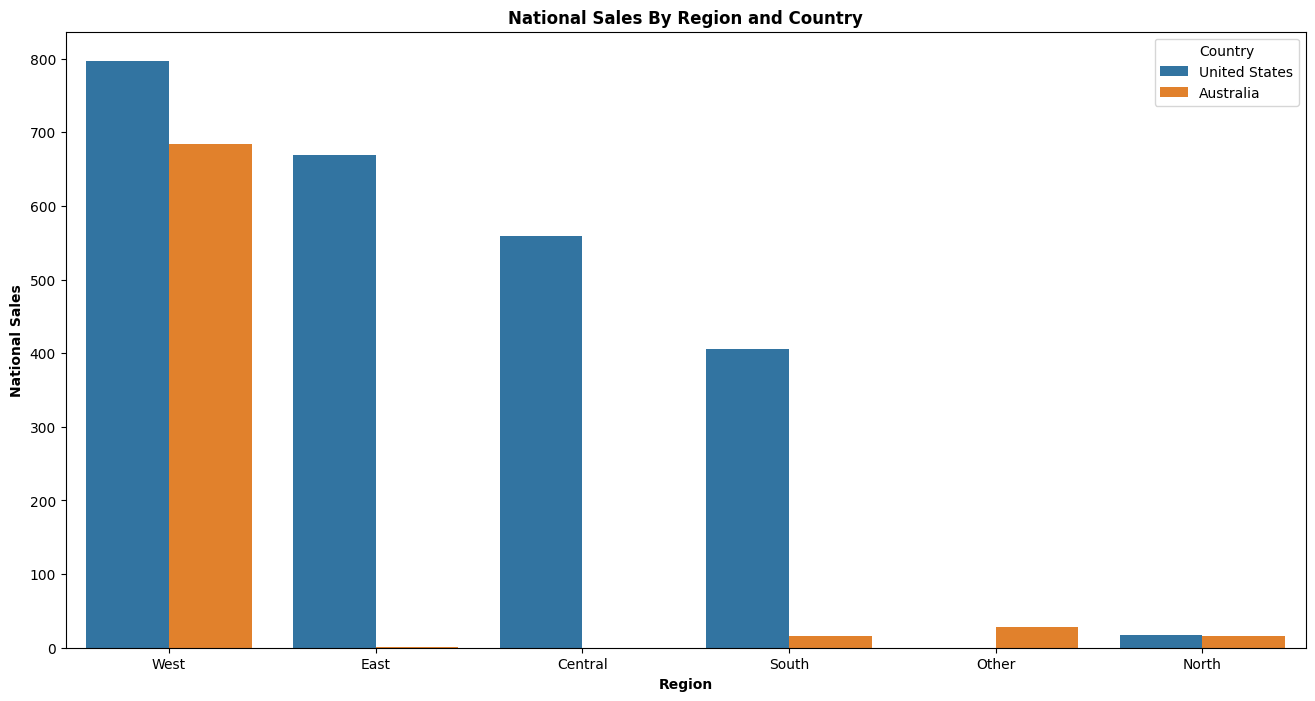

In [44]:
 #Data visualization
#create a bar chart
National_Sales=df.groupby(['Region','Country'])['National Sales'].sum().reset_index().sort_values(by='National Sales',ascending=False)
National_Sales
plt.figure(figsize=(16,8))
sns.barplot(data=National_Sales,x='Region',y='National Sales',hue='Country')
plt.title('National Sales By Region and Country',fontweight='bold')
plt.xlabel('Region',fontweight='bold')
plt.ylabel('National Sales',fontweight='bold')
plt.show()

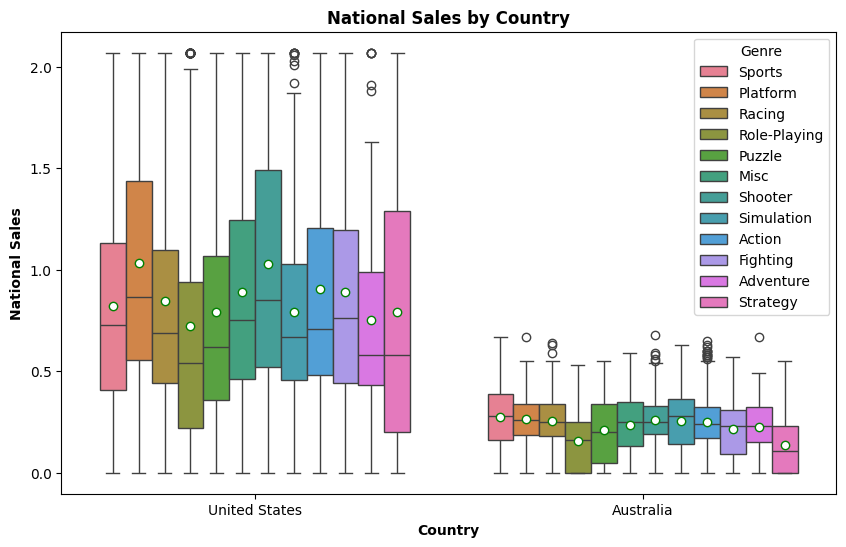

In [51]:
#Create Box Plot
plt.figure(figsize=(10,6))
sns.boxplot(x='Country',y='National Sales',data=df,showmeans=True,hue='Genre',meanprops={'marker':'o','markerfacecolor':'white','markersize':'6','markeredgecolor':'green'})
plt.title('National Sales by Country',fontweight='bold')
plt.xlabel('Country',fontweight='bold')
plt.ylabel('National Sales',fontweight='bold')
plt.show()

Text(0.5, 1.0, 'Global Sales by Country')

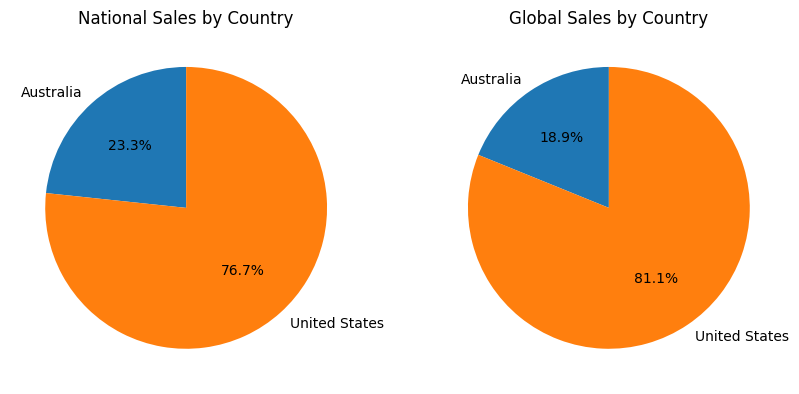

In [64]:
#Create a pie chart
Sales=df.groupby(['Country'])[['National Sales','Global Sales']].sum().reset_index()
Country=Sales['Country']
National_Sales=Sales['National Sales']
Global_Sales=Sales['Global Sales']
fig,axs=plt.subplots(1,2,figsize=(10,7))
axs[0].pie(National_Sales,labels=Country,autopct='%1.1f%%',startangle=90)
axs[0].set_title('National Sales by Country')
axs[1].pie(Global_Sales,labels=Country,autopct='%1.1f%%',startangle=90)
axs[1].set_title('Global Sales by Country')

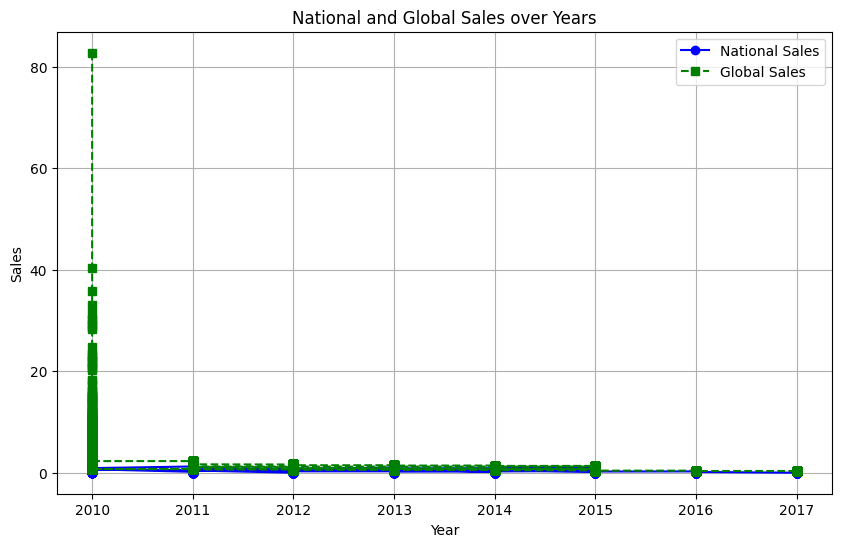

In [67]:
#Create a line chart
plt.figure(figsize=(10,6))
#Line for National Sales
plt.plot(df['Year'],df['National Sales'],marker='o',linestyle='-',color='b',label='National Sales')
#Line for Global Sales
plt.plot(df['Year'],df['Global Sales'],marker='s',linestyle='--',color='g',label='Global Sales')
#Adding titles and labels
plt.title('National and Global Sales over Years')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.legend()
#Display the line chart
plt.grid(True)
plt.show()